# Notebook 4: EDA (the detailed one)

In [1]:
import sys
assert "olist_mlops" in sys.executable, f"wrong kernel selected in the editor - expected the olist_mlops env, got: {sys.executable}"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## read the train split only

val and test stay untouched until notebook 6, so any decision we make here can't leak from them.

In [3]:
ARTIFACTS_DIR = Path("artifacts")
CHARTS_DIR = Path("charts") / "04_eda_charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

id_cols = ["order_id", "customer_id", "main_seller_id"]
cat_cols = ["customer_state", "seller_state", "main_product_category", "main_payment_type"]
num_cols = ["n_items", "n_distinct_products", "n_distinct_sellers", "total_price",
            "total_freight_value", "avg_item_price", "total_weight_g",
            "total_payment_value", "max_installments", "n_payment_methods"]
date_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
             "order_delivered_customer_date", "order_estimated_delivery_date"]

In [4]:
df = pd.read_csv(ARTIFACTS_DIR / "03_train.csv")
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df.shape

(67533, 26)

## data types, shape, memory

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67533 entries, 0 to 67532
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       67533 non-null  str           
 1   customer_id                    67533 non-null  str           
 2   order_status                   67533 non-null  str           
 3   order_purchase_timestamp       67533 non-null  datetime64[us]
 4   order_approved_at              67519 non-null  datetime64[us]
 5   order_delivered_carrier_date   67532 non-null  datetime64[us]
 6   order_delivered_customer_date  67533 non-null  datetime64[us]
 7   order_estimated_delivery_date  67533 non-null  datetime64[us]
 8   customer_state                 67533 non-null  str           
 9   customer_zip_code_prefix       67533 non-null  int64         
 10  n_items                        67533 non-null  float64       
 11  n_distinct_products       

In [6]:
print("memory usage (MB):", round(df.memory_usage(deep=True).sum() / 1e6, 2))

memory usage (MB): 49.48


## missing values

In [7]:
nulls = df.isna().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
null_pct = (nulls / len(df) * 100).round(2)

pd.DataFrame({"n_missing": nulls, "pct_missing": null_pct})

,n_missing,pct_missing
main_product_category,1221,1.81
order_approved_at,14,0.02
order_delivered_carrier_date,1,0.00
total_payment_value,1,0.00
max_installments,1,0.00
n_payment_methods,1,0.00
main_payment_type,1,0.00


bar chart of % missing per column, smallest to largest.

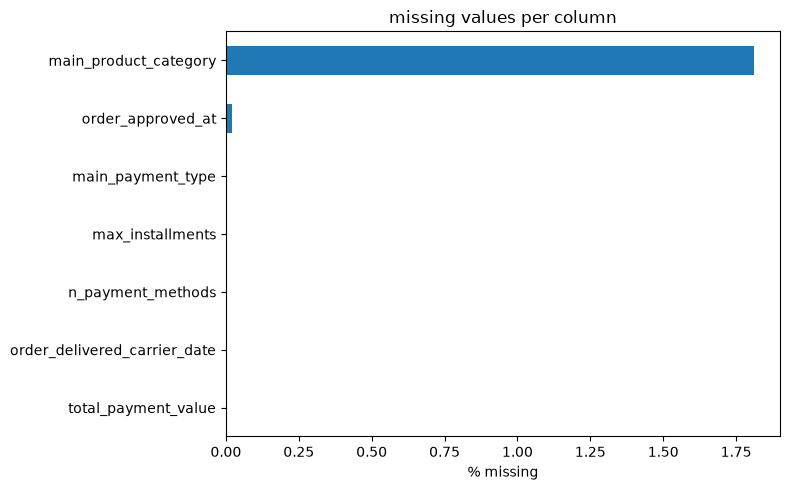

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
null_pct.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("% missing")
ax.set_title("missing values per column")
fig.tight_layout()
fig.savefig(CHARTS_DIR / "01_missing_values.png")
plt.show()

the item/payment/seller columns (~1% of orders) are missing because those orders have no rows
in `order_items` at all - that's a real data gap in the source, not random. `main_product_category`
has a bit more missing on top of that, from items whose product has no category listed.

## numerical features

In [9]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
n_items,67533.0,1.142079,0.541635,1.000000,1.00,1.00,1.000,21.00
n_distinct_products,67533.0,1.037715,0.222223,1.000000,1.00,1.00,1.000,7.00
n_distinct_sellers,67533.0,1.012053,0.114812,1.000000,1.00,1.00,1.000,5.00
total_price,67533.0,135.884499,205.187627,2.290000,45.90,85.00,149.900,13440.00
total_freight_value,67533.0,22.244256,19.999582,0.000000,14.10,16.79,23.700,1002.29
avg_item_price,67533.0,124.234649,185.653751,1.514286,41.00,78.97,139.900,6735.00
total_weight_g,67533.0,2465.215835,4909.093564,0.000000,300.00,800.00,2150.000,184400.00
total_payment_value,67532.0,158.167657,214.277783,10.070000,61.63,104.19,175.485,13664.08
max_installments,67532.0,2.974397,2.755007,1.000000,1.00,2.00,4.000,24.00
n_payment_methods,67532.0,1.024018,0.153107,1.000000,1.00,1.00,1.000,2.00


In [10]:
skew = df[num_cols].skew().sort_values(ascending=False)
skew

total_price            10.719309
n_distinct_sellers     10.525258
total_payment_value    10.149896
total_freight_value     8.584291
n_items                 8.106935
avg_item_price          7.802797
n_distinct_products     7.675360
total_weight_g          6.645649
n_payment_methods       6.217825
max_installments        1.592864
dtype: float64

histogram grid, one distribution per numeric column.

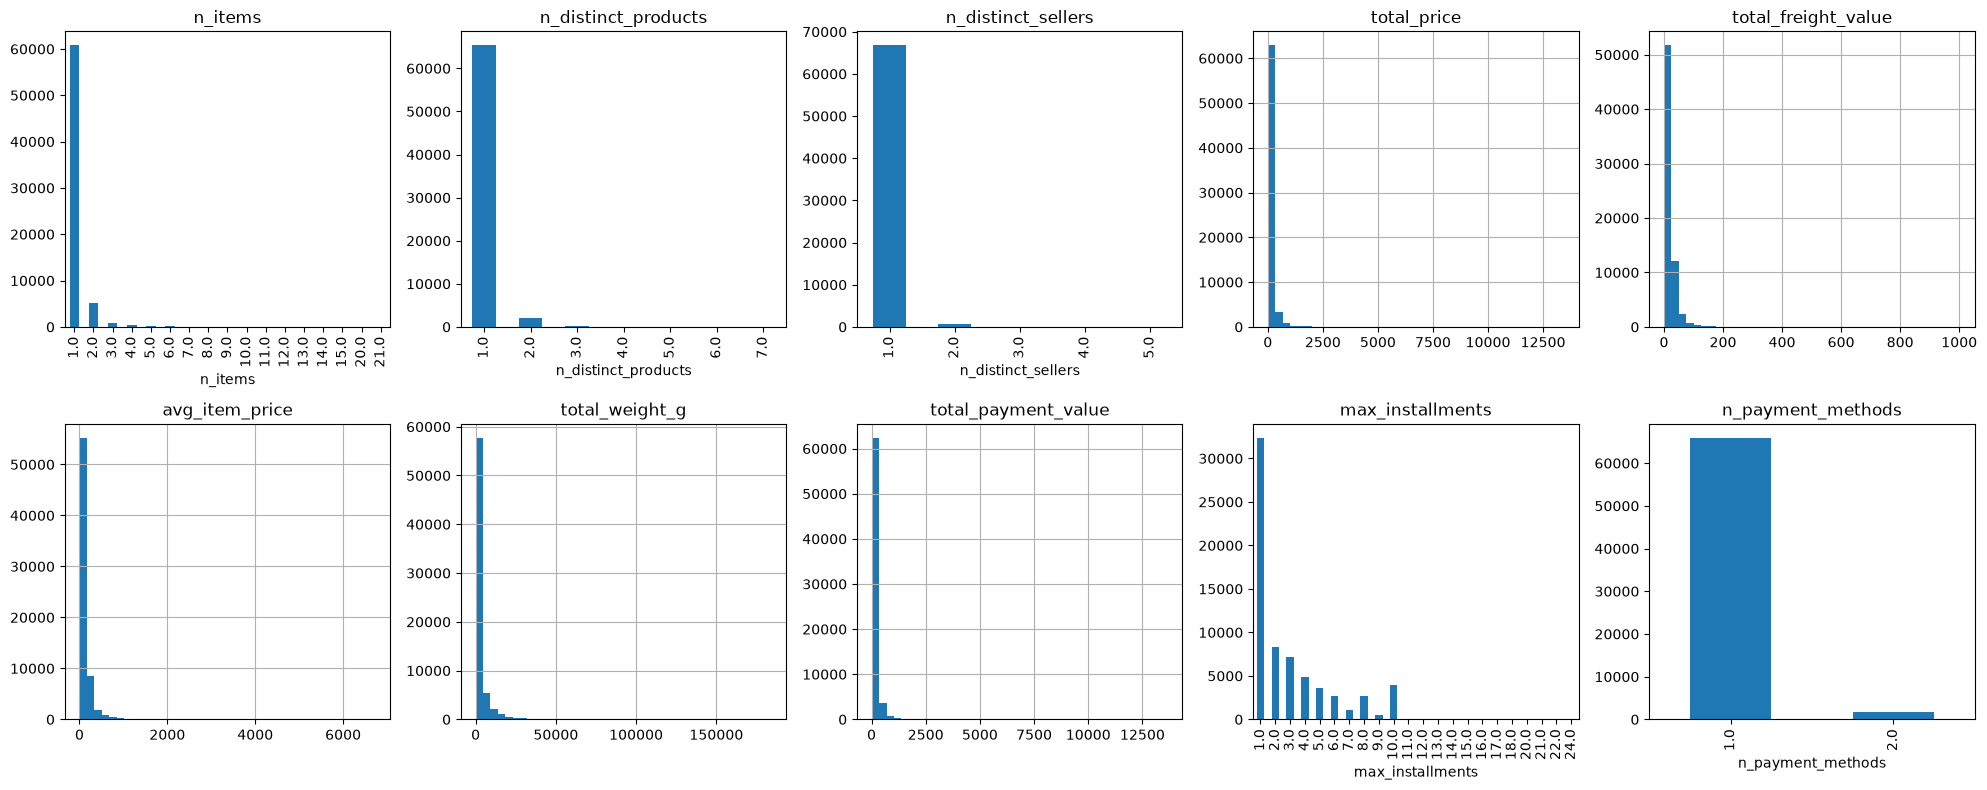

In [11]:
discrete_like = ["n_items", "n_distinct_products", "n_distinct_sellers", "max_installments", "n_payment_methods"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, num_cols):
    if col in discrete_like:
        # small integer range, a bar chart of the actual values reads better than a 40-bin histogram
        df[col].value_counts().sort_index().plot(kind="bar", ax=ax)
    else:
        df[col].hist(ax=ax, bins=40)
    ax.set_title(col)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "02_numeric_histograms.png")
plt.show()

boxplot grid, one box per numeric column, to spot outliers.

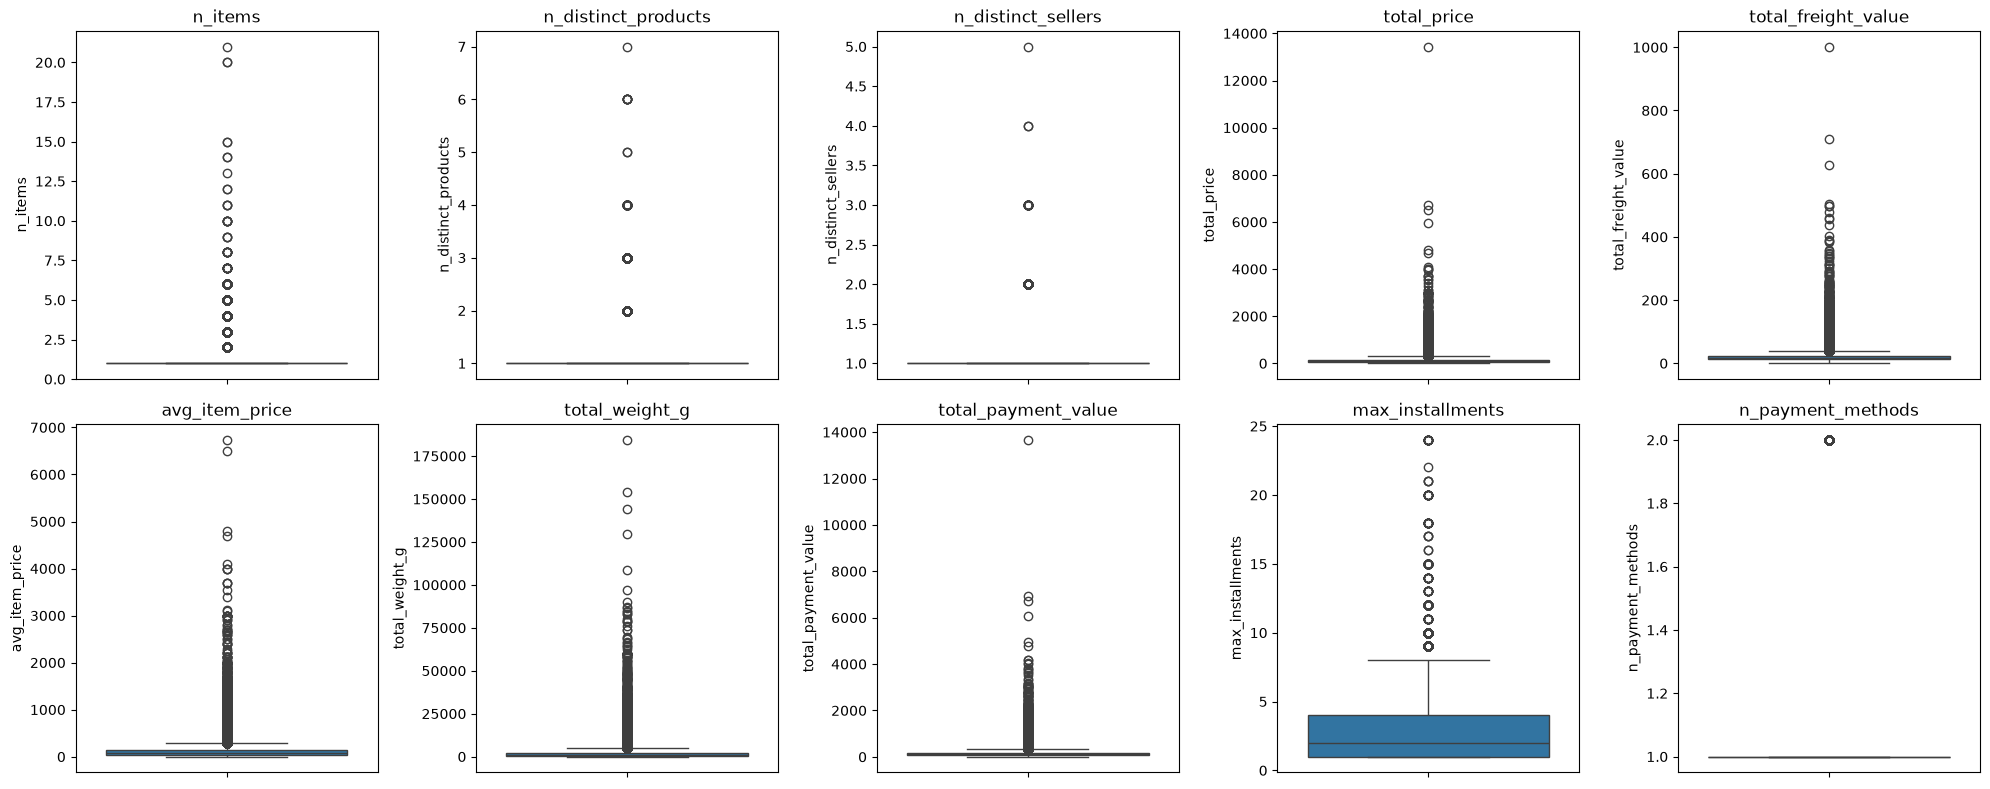

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "03_numeric_boxplots.png")
plt.show()

In [13]:
# ranges that make no sense
zero_neg_counts = (df[num_cols] <= 0).sum()
zero_neg_counts = zero_neg_counts[zero_neg_counts > 0]

print("columns with zero/negative values:")
print(zero_neg_counts if len(zero_neg_counts) else "none found")

print("\nbiggest total_price:", df["total_price"].max())
print("biggest total_freight_value:", df["total_freight_value"].max())

columns with zero/negative values:
total_freight_value    10
total_weight_g         16
dtype: int64

biggest total_price: 13440.0
biggest total_freight_value: 1002.29


## categorical features

In [14]:
for col in cat_cols:
    print(col, "-", df[col].nunique(), "distinct values")

customer_state - 27 distinct values
seller_state - 22 distinct values
main_product_category - 72 distinct values
main_payment_type - 4 distinct values


bar charts of order counts by customer_state, seller_state, main_payment_type, and the top 15 product categories.

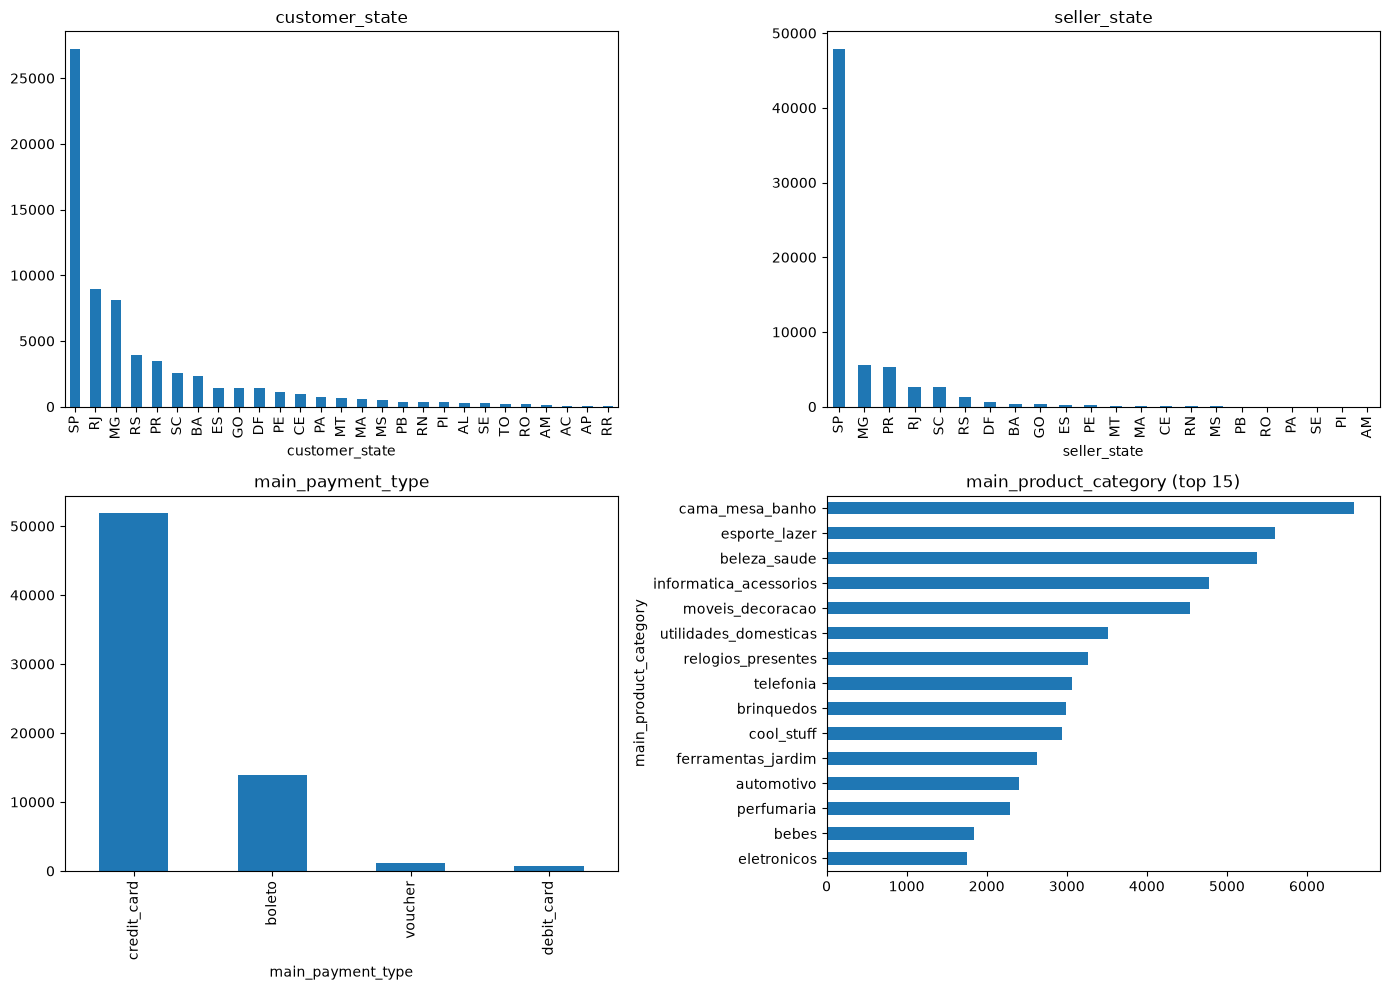

In [15]:
top_categories = df["main_product_category"].value_counts().head(15)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df["customer_state"].value_counts().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("customer_state")

df["seller_state"].value_counts().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("seller_state")

df["main_payment_type"].value_counts().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("main_payment_type")

top_categories.plot(kind="barh", ax=axes[1, 1])
axes[1, 1].invert_yaxis()
axes[1, 1].set_title("main_product_category (top 15)")

fig.tight_layout()
fig.savefig(CHARTS_DIR / "04_categorical_counts.png")
plt.show()

In [16]:
category_share = df["main_product_category"].value_counts(normalize=True) * 100
rare_categories = category_share[category_share < 1]
print(f"{len(rare_categories)} categories are each under 1% of orders - candidates for an 'other' bucket")

51 categories are each under 1% of orders - candidates for an 'other' bucket


## relations to the label

In [17]:
df.groupby('late')[num_cols].mean().T

late,0,1
n_items,1.144834,1.114319
n_distinct_products,1.039228,1.022470
n_distinct_sellers,1.012989,1.002624
total_price,134.506741,149.767376
total_freight_value,21.950632,25.202941
avg_item_price,122.632952,140.374029
total_weight_g,2435.216192,2767.505166
total_payment_value,156.496706,175.007633
max_installments,2.959486,3.124672
n_payment_methods,1.024367,1.020505


late rate bar charts by customer_state, seller_state, main_payment_type, and top 15 product categories. red dashed line = overall late rate.

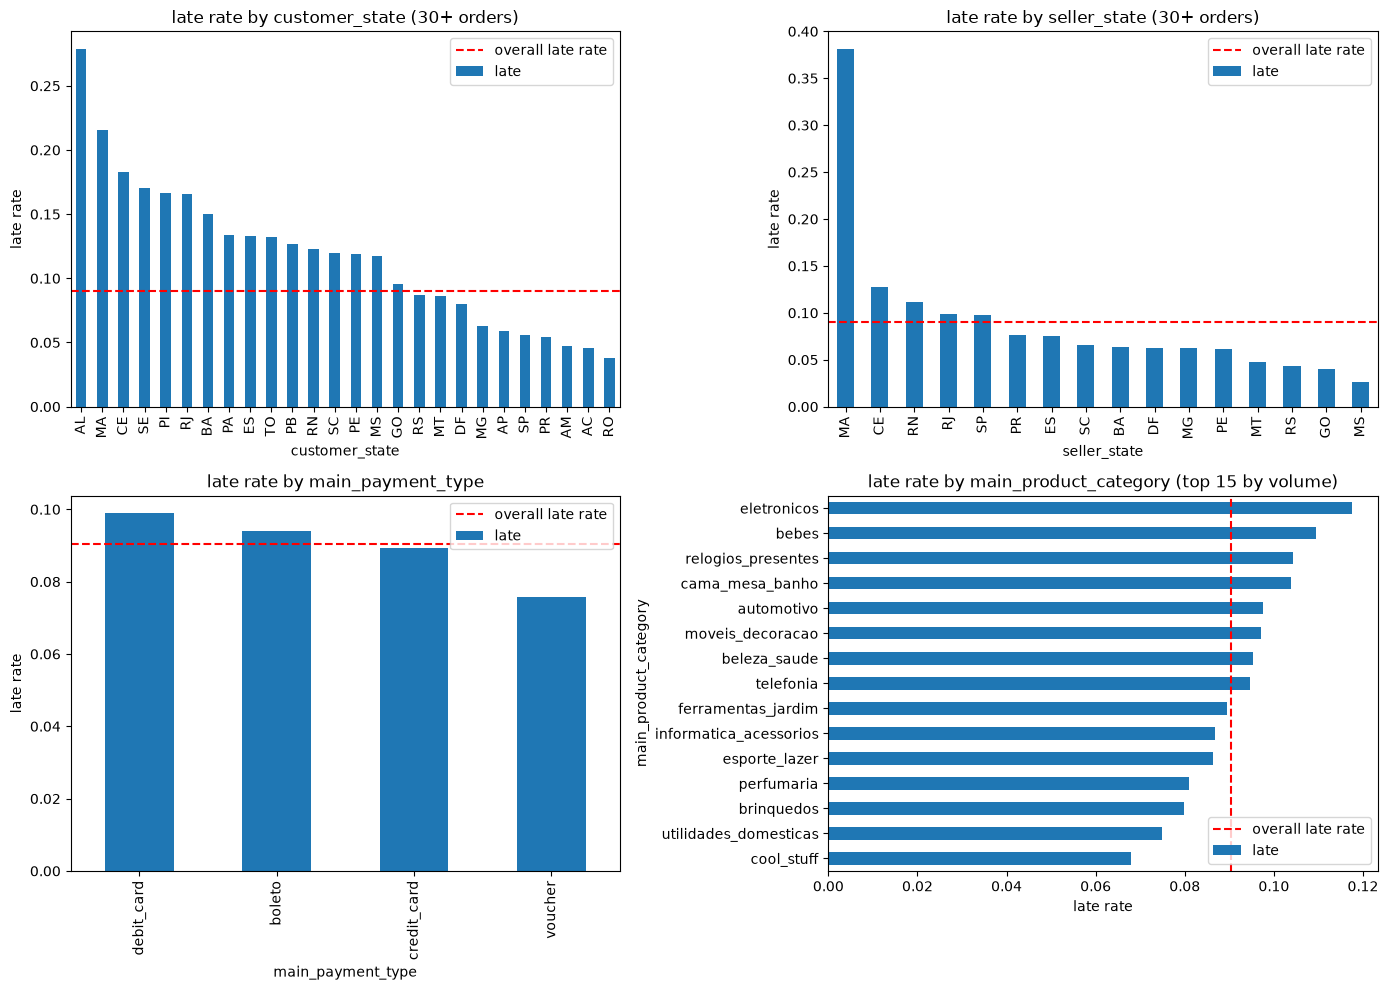

In [18]:
overall_late_rate = df["late"].mean()

def late_rate_by(col, min_count=30):
    # small states can have wild rates just from having few orders, drop anything under min_count
    counts = df[col].value_counts()
    valid = counts[counts >= min_count].index
    return df[df[col].isin(valid)].groupby(col)["late"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

late_rate_by("customer_state").plot(kind="bar", ax=axes[0, 0])
axes[0, 0].axhline(overall_late_rate, color="red", linestyle="--", label="overall late rate")
axes[0, 0].set_ylabel("late rate")
axes[0, 0].set_title("late rate by customer_state (30+ orders)")
axes[0, 0].legend()

late_rate_by("seller_state").plot(kind="bar", ax=axes[0, 1])
axes[0, 1].axhline(overall_late_rate, color="red", linestyle="--", label="overall late rate")
axes[0, 1].set_ylabel("late rate")
axes[0, 1].set_title("late rate by seller_state (30+ orders)")
axes[0, 1].legend()

df.groupby("main_payment_type")["late"].mean().sort_values(ascending=False).plot(kind="bar", ax=axes[1, 0])
axes[1, 0].axhline(overall_late_rate, color="red", linestyle="--", label="overall late rate")
axes[1, 0].set_ylabel("late rate")
axes[1, 0].set_title("late rate by main_payment_type")
axes[1, 0].legend()

top_cat_names = top_categories.index
cat_rates = (
    df[df["main_product_category"].isin(top_cat_names)]
    .groupby("main_product_category")["late"]
    .mean()
    .sort_values(ascending=True)  # ascending so the highest ends up on top of the barh
)
cat_rates.plot(kind="barh", ax=axes[1, 1])
axes[1, 1].axvline(overall_late_rate, color="red", linestyle="--", label="overall late rate")
axes[1, 1].set_xlabel("late rate")
axes[1, 1].set_title("late rate by main_product_category (top 15 by volume)")
axes[1, 1].legend()

fig.tight_layout()
fig.savefig(CHARTS_DIR / "05_late_rate_by_category.png")
plt.show()

states with fewer than 30 orders in this split are excluded from the state charts - with that
few orders a single late delivery swings the rate a lot, which was making the chart misleading.

correlation heatmap between the numeric features and the label.

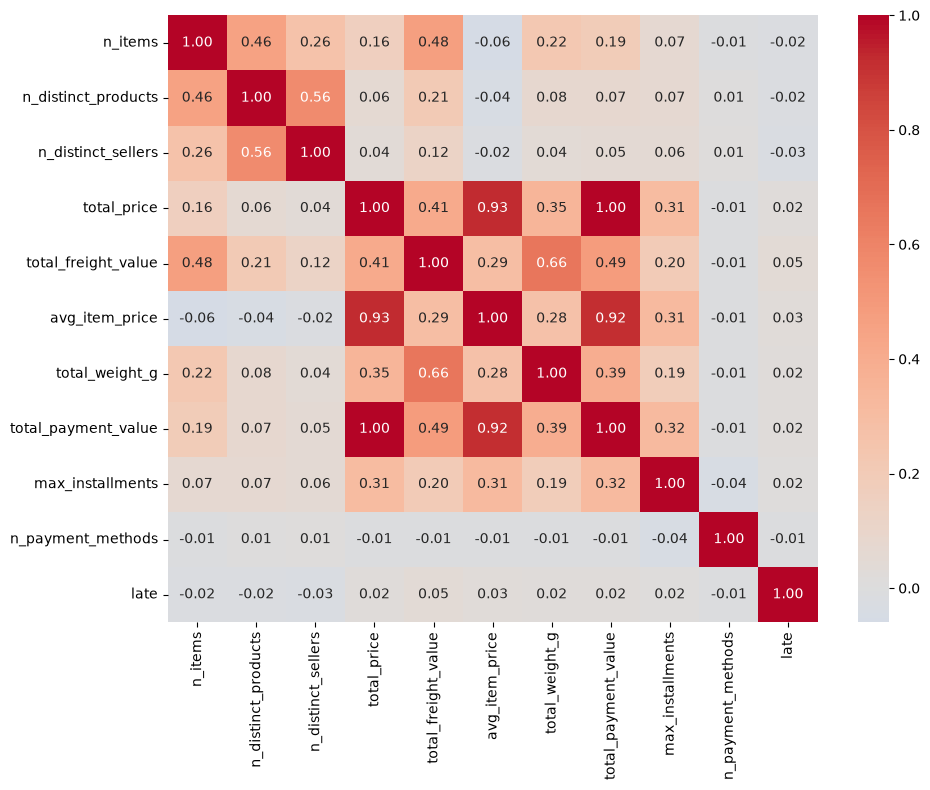

In [19]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols + ["late"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "06_correlation_heatmap.png")
plt.show()

boxplot grid comparing late vs on time orders across 6 numeric features.

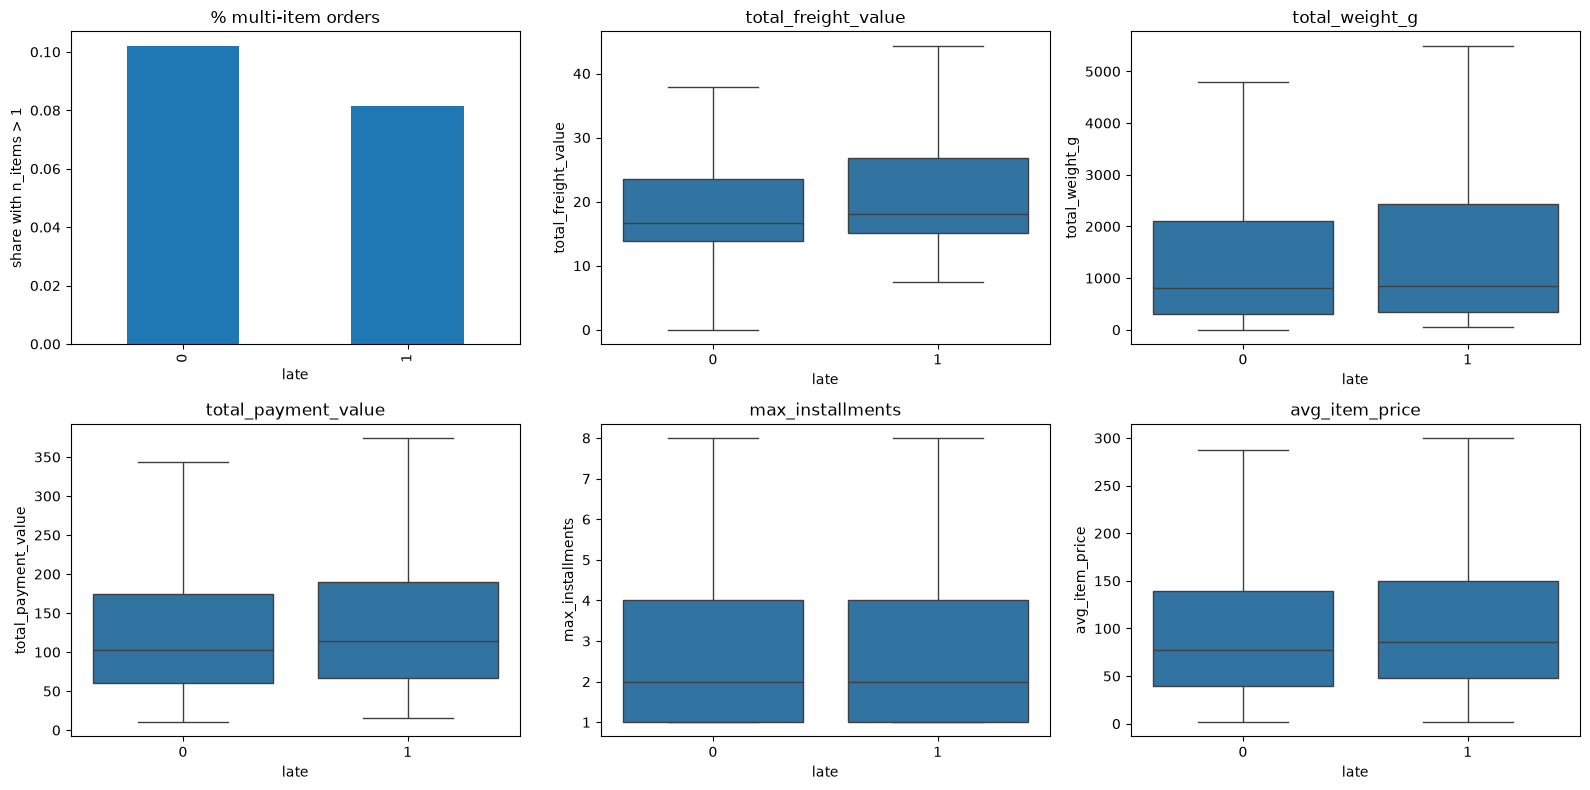

In [20]:
box_cols = ["total_freight_value", "total_weight_g", "total_payment_value", "max_installments", "avg_item_price"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# n_items is 1 for ~88% of orders, so a boxplot of it split by label is just two flat lines -
# compare the % of multi-item orders instead, that's the part that can actually differ by label
multi_item_rate = df.groupby("late")["n_items"].apply(lambda s: (s > 1).mean())
multi_item_rate.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("% multi-item orders")
axes[0, 0].set_ylabel("share with n_items > 1")

for ax, col in zip(axes.flat[1:], box_cols):
    sns.boxplot(data=df, x="late", y=col, ax=ax, showfliers=False)
    ax.set_title(col)

fig.tight_layout()
fig.savefig(CHARTS_DIR / "07_numeric_by_label.png")
plt.show()

## dates - seasonality, weekday, promised delivery window

In [21]:
# just for looking around here, notebook 5 rebuilds whichever of these turn out useful
df["purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
df["purchase_dow"] = df["order_purchase_timestamp"].dt.day_name()
df["promised_days"] = (df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]).dt.days

orders per month, late rate per month, late rate per weekday, and the promised delivery window distribution.

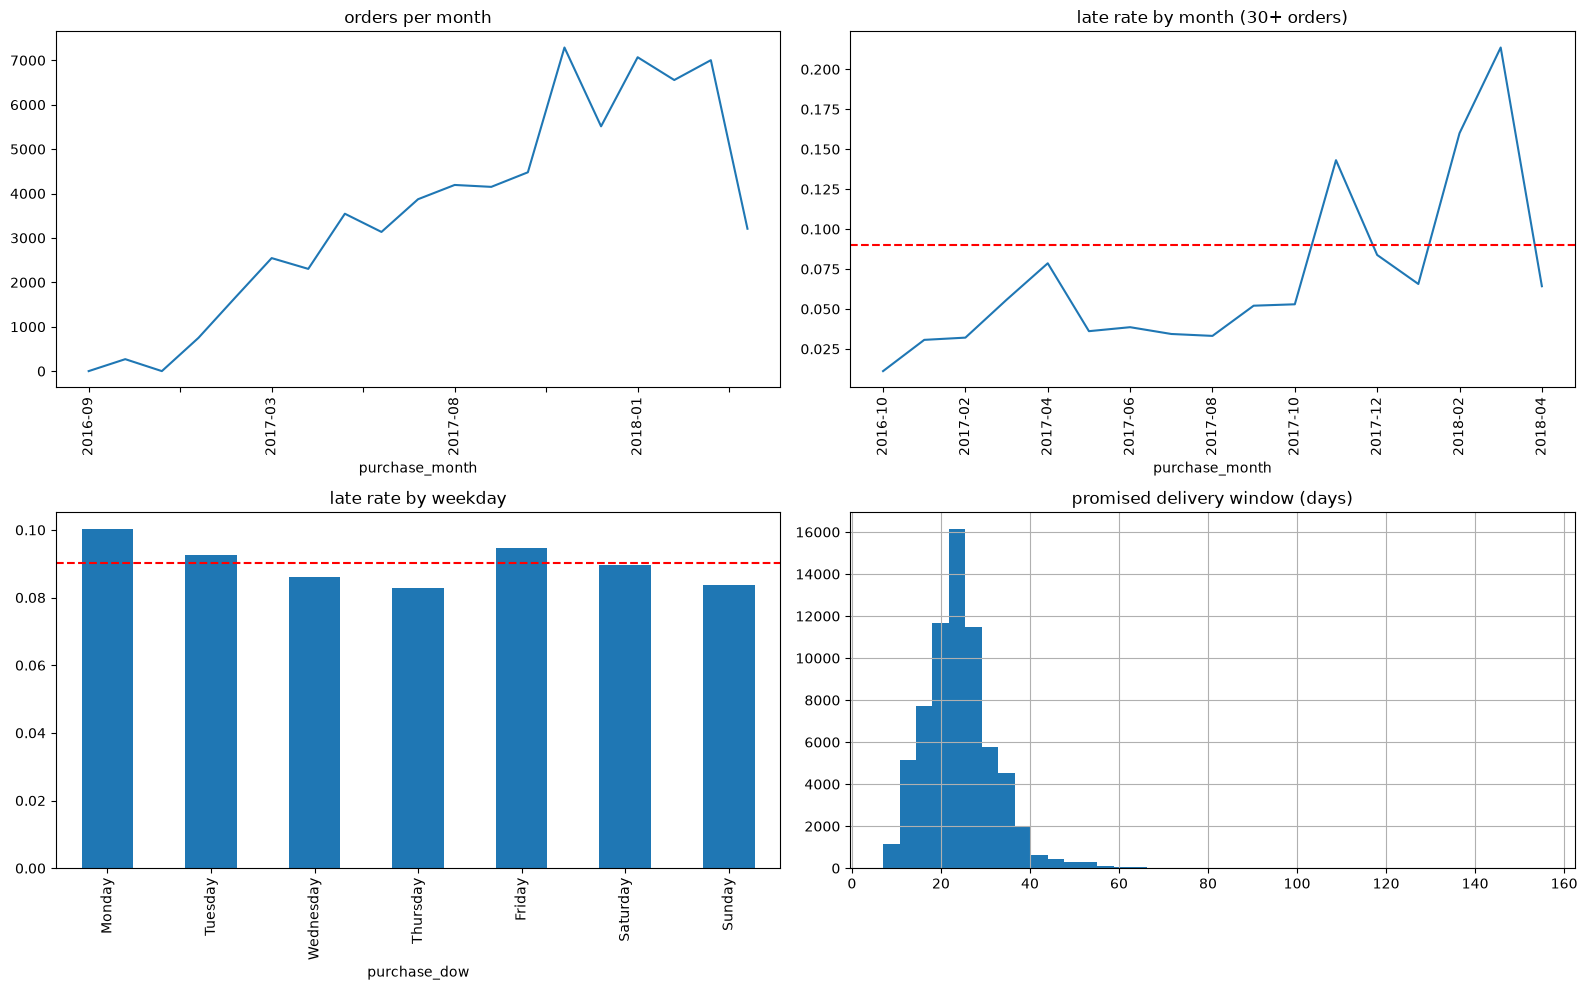

In [22]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# same small-sample trap as the state charts - the first couple of months are Olist's pilot
# period with almost no orders, one late delivery there would swing the rate to 0% or 100%
month_counts = df["purchase_month"].value_counts()
valid_months = month_counts[month_counts >= 30].index

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df.groupby("purchase_month").size().plot(ax=axes[0, 0])
axes[0, 0].set_title("orders per month")
axes[0, 0].tick_params(axis="x", rotation=90)

df[df["purchase_month"].isin(valid_months)].groupby("purchase_month")["late"].mean().plot(ax=axes[0, 1])
axes[0, 1].axhline(overall_late_rate, color="red", linestyle="--")
axes[0, 1].set_title("late rate by month (30+ orders)")
axes[0, 1].tick_params(axis="x", rotation=90)

df.groupby("purchase_dow")["late"].mean().reindex(dow_order).plot(kind="bar", ax=axes[1, 0])
axes[1, 0].axhline(overall_late_rate, color="red", linestyle="--")
axes[1, 0].set_title("late rate by weekday")

df["promised_days"].hist(bins=40, ax=axes[1, 1])
axes[1, 1].set_title("promised delivery window (days)")

fig.tight_layout()
fig.savefig(CHARTS_DIR / "08_dates_seasonality.png")
plt.show()

late rate bucketed by the promised delivery window length (days).

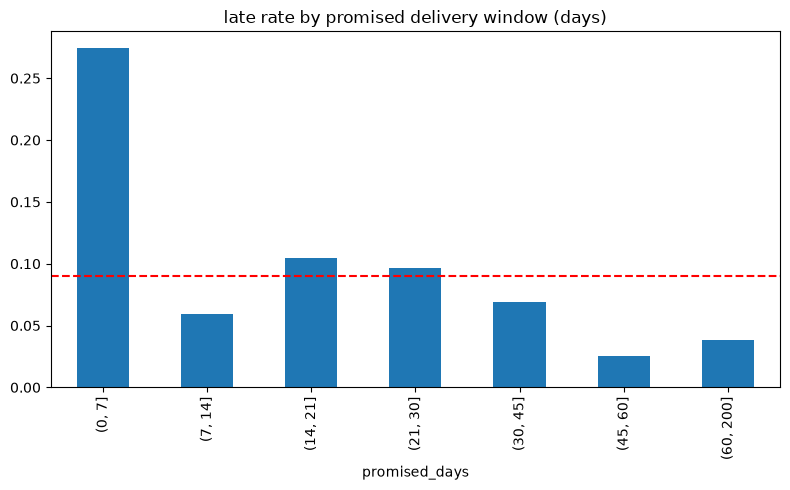

In [23]:
promised_bucket = pd.cut(df["promised_days"], bins=[0, 7, 14, 21, 30, 45, 60, 200])

fig, ax = plt.subplots(figsize=(8, 5))
df.groupby(promised_bucket)["late"].mean().plot(kind="bar", ax=ax)
ax.axhline(overall_late_rate, color="red", linestyle="--")
ax.set_title("late rate by promised delivery window (days)")
fig.tight_layout()
fig.savefig(CHARTS_DIR / "09_promised_window_vs_late.png")
plt.show()

## geography

In [24]:
print("customer_zip_code_prefix distinct:", df["customer_zip_code_prefix"].nunique())
print("seller_zip_code_prefix distinct:", df["seller_zip_code_prefix"].nunique())

# too many distinct values to use directly as a feature, state is the usable granularity here

customer_zip_code_prefix distinct: 13748
seller_zip_code_prefix distinct: 1681


late rate comparing same-state vs different-state shipments.

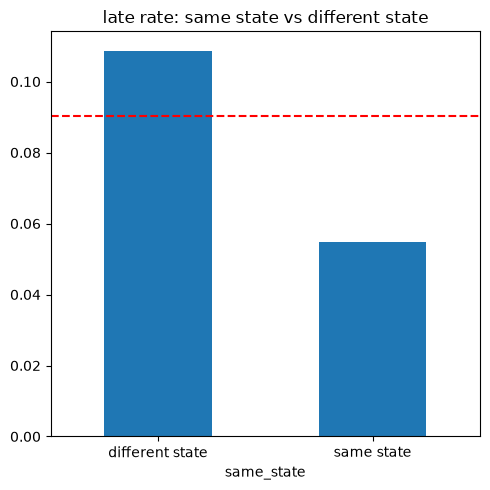

In [25]:
df["same_state"] = df["customer_state"] == df["seller_state"]

fig, ax = plt.subplots(figsize=(5, 5))
df.groupby("same_state")["late"].mean().plot(kind="bar", ax=ax)
ax.axhline(overall_late_rate, color="red", linestyle="--")
ax.set_xticklabels(["different state", "same state"], rotation=0)
ax.set_title("late rate: same state vs different state")
fig.tight_layout()
fig.savefig(CHARTS_DIR / "10_geography_same_state.png")
plt.show()

`distance_km` isn't in this table - it got dropped back in notebook 1 since it needed an extra
computed step (not just a count/sum), and we decided that belongs in feature engineering, not
here. if the same-state pattern above looks meaningful, it's worth going back and adding it.

## findings

In [26]:
zero_neg_counts = (df[num_cols] <= 0).sum()
zero_neg_counts = zero_neg_counts[zero_neg_counts > 0]
top_skew_cols = list(skew.head(3).index)

findings = f"""# EDA findings (notebook 4, train split only)

rows: {len(df)}, columns: {df.shape[1]}
overall late rate: {overall_late_rate:.4f}

## missing values
{nulls.to_string()}
mostly from the ~1% of orders with no order_items rows, not random missingness.

## numerical
most skewed columns: {top_skew_cols}
columns with zero/negative values: {zero_neg_counts.to_string() if len(zero_neg_counts) else "none found"}
- 15 of the 16 zero-weight rows also have a missing main_product_category - same root cause
  (item's product_id has no match in the products table), not a separate problem.
- 9 of the 10 zero-freight rows are in cama_mesa_banho (bed/bath/linens) - looks like a real
  free-shipping pattern for that category rather than a data error, worth a second look in
  notebook 5 before treating it as missing/invalid.

total_price and total_payment_value are correlated at 1.00 - basically the same number
(payment ~= price + freight), so total_payment_value is redundant and should be dropped.
avg_item_price is also correlated with total_price at 0.93 but is worth keeping anyway,
it's total_price / n_items and a model can't reconstruct that ratio from the other two on its own.

n_items, max_installments etc are small integer counts, not continuous - plotted as bar charts
of their actual values instead of 40-bin histograms, reads a lot cleaner.

## categorical
main_product_category has {df["main_product_category"].nunique()} distinct values,
{len(rare_categories)} of them under 1% of orders each - bucket these as "other" in notebook 5.

## relations to label
late rate varies noticeably by state, payment type and product category
(see 05_late_rate_by_category.png). correlation with the numeric features alone is weak
(see 06_correlation_heatmap.png) - lateness looks more driven by categorical/geo/time factors
than by one strong numeric predictor. n_items itself is ~88% single-item orders, so a boxplot
split by label was flat/useless - compared % multi-item orders by label instead
(see 07_numeric_by_label.png).

## dates
the first couple of months (2016-09, 2016-12) have only 1 order each - one of them being late
swung the "late rate by month" line to 100%/0%, pure small-sample noise, not signal. excluded
months with under 30 orders from that chart (same fix applied to state charts earlier).
late rate differs a bit by weekday (~0.08 to ~0.10), a small effect.

the promised delivery window relationship isn't a simple "shorter = later" story:
- (0-7 days]: 27% late, but only 62 orders in this split - thin sample, treat with caution
- (7-14 days]: 5.9% late (n=6204) - the lowest well-sampled bucket
- (14-21] and (21-30]: 10.5% and 9.7% late (n=19401, 29734) - the bulk of orders, both above average
- beyond 30 days: late rate falls off (6.9% -> 2.6% -> 3.8%) as the buffer gets more generous
so the real pattern is "the 2-4 week range is riskiest", not a straight line.

## geography
same-state vs different-state shipments show a late rate difference (see 10 chart).
distance_km itself isn't available here - it was dropped from notebook 1 since it needed an
extra computed step. worth re-adding if this looks worth pursuing further.

## decisions for notebook 5
- bucket rare product categories into "other" before encoding
- derive purchase_dow, purchase_month, promised_days as real features
- impute missing numeric/categorical values (orders with no items)
- drop id columns and the raw delivered-date columns (leakage)
- drop total_payment_value (redundant with total_price + total_freight_value)
- double check whether zero-freight cama_mesa_banho orders are a real promotion before imputing them
- revisit adding distance_km if geography turns out to matter more
"""

with open(ARTIFACTS_DIR / "04_findings.md", "w") as f:
    f.write(findings)

print(findings)

# EDA findings (notebook 4, train split only)

rows: 67533, columns: 30
overall late rate: 0.0903

## missing values
main_product_category           1221
order_approved_at                 14
order_delivered_carrier_date       1
total_payment_value                1
max_installments                   1
n_payment_methods                  1
main_payment_type                  1
mostly from the ~1% of orders with no order_items rows, not random missingness.

## numerical
most skewed columns: ['total_price', 'n_distinct_sellers', 'total_payment_value']
columns with zero/negative values: total_freight_value    10
total_weight_g         16
- 15 of the 16 zero-weight rows also have a missing main_product_category - same root cause
  (item's product_id has no match in the products table), not a separate problem.
- 9 of the 10 zero-freight rows are in cama_mesa_banho (bed/bath/linens) - looks like a real
  free-shipping pattern for that category rather than a data error, worth a second look in
  n